# GPGN268 - Geophysical Data Analysis
## Final Project - Martian Subsurface Analysis

**Students:** Petra Elrod, Shleby Layne, Addy Peterson
**Collaborators:**

**Date:** 1 May 2026

## Introduction / Problem Statement

**1. Data Processing:**

In [15]:
#Imports

import pandas as pd
import matplotlib.pyplot as plt

import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from datetime import datetime

In [16]:
# 1. Define a function to read the mars catalog file
def load_mars_catalog(filename, quality_label):
    
    cols = ['Event_ID', 'Timestamp', 'Distance', 'Quality', 'Class']
    
    df = pd.read_csv(filename, sep='\s+', names=cols, on_bad_lines='skip')
    
    df['Quality'] = quality_label
    return df

# 2. Load the data
df_a = load_mars_catalog('high_quality_events/quality_A_events.txt', 'A')
df_b = load_mars_catalog('high_quality_events/quality_B_events.txt', 'B')

# 3. Combine into one master DataFrame for the group
df_total = pd.concat([df_a, df_b], ignore_index=True)

# 4. Convert Timestamp to actual datetime objects for math later
df_total['Timestamp'] = pd.to_datetime(df_total['Timestamp'], errors='coerce')

# 5. Quick look at the "Evidence"
print(f"Successfully loaded {len(df_total)} events.")

#Save as a new data file
df_total.to_csv('marsquakes_data_frame.csv', index=False) #We can rename this file to

df_total.head(5)

Successfully loaded 185 events.


<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/60/trjb6m6100qft2g2gpz2xqh00000gn/T/ipykernel_65397/4079573029.py:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv(filename, sep='\s+', names=cols, on_bad_lines='skip')


,Event_ID,Timestamp,Distance,Quality,Class
0,S1222a,2022-05-04 23:23:07.856945+00:00,37.01,A,BROADBAND
1,S1133c,2022-02-03 08:04:38.145711+00:00,30.19,A,BROADBAND
2,S1102a,2022-01-02 04:27:10.093677+00:00,73.31,A,BROADBAND
3,S1094b,2021-12-24 22:38:02.749173+00:00,59.65,A,BROADBAND
4,S1048d,2021-11-07 22:00:15.254098+00:00,30.19,A,LOW_FREQUENCY


In [17]:
#Parse the xml file to get the vp and vs waves

# 1. Load the XML data
xml_file = 'dev/events_mars_extended_multiorigin_v12_2022-07-01.xml'
tree = ET.parse(xml_file)
root = tree.getroot()

#Create a custom xml parser
def get_event_picks(event_id, root):
    """
    Finds the earliest P-wave and the first S-wave arriving after it.
    Bypasses XML namespaces using wildcards.
    """
    for event in root.findall('.//{*}event'):
        public_id = event.get('publicID', '')
        # Extract all text in the event block to find a specific ID
        all_text = "".join([t.text for t in event.findall('.//{*}text') if t.text])
        
        if event_id.lower() in public_id.lower() or event_id.lower() in all_text.lower():
            # Find the Origin Time (t0)
            origin_node = event.find('.//{*}origin/{*}time/{*}value')
            t0 = origin_node.text if origin_node is not None else None
            
            p_arrivals, s_arrivals = [], []
            
            # Search through all 'picks' for P and S phase hints
            for pick in event.findall('.//{*}pick'):
                phase = pick.find('{*}phaseHint')
                time_node = pick.find('{*}time/{*}value')
                
                if phase is not None and time_node is not None:
                    p_text = phase.text.upper()
                    t_val = time_node.text
                    if 'P' in p_text: p_arrivals.append(t_val)
                    elif 'S' in p_text: s_arrivals.append(t_val)
            
            # Physics Constraint: Earliest P, and the first S that happens AFTER P
            if p_arrivals and s_arrivals:
                tp = min(p_arrivals)
                valid_s = [s for s in s_arrivals if s > tp]
                if valid_s:
                    ts = min(valid_s)
                    return t0, tp, ts
                    
    return None, None, None

In [18]:
# 1. Create a new dataframe from total data
# Grab inmportant info we already have to initiate a new dataframe
seismic_df = df_total[['Event_ID','Distance']].copy()

# 2. Add the empty columns 
seismic_df['t0'] = None
seismic_df['tp'] = None
seismic_df['ts'] = None
seismic_df['Vp_Vs_Ratio'] = np.nan

print(f"Starting calculation for {len(seismic_df)} events...")

# 3. Run the Robust Calculation Loop
for index, row in seismic_df.iterrows():
    t0, tp, ts = get_event_picks(row['Event_ID'], root)
    
    seismic_df.at[index, 't0'] = t0
    seismic_df.at[index, 'tp'] = tp
    seismic_df.at[index, 'ts'] = ts

    # Calculate if all phases were found
    if all([t0, tp, ts]):
        try:
            # ISO format for NASA InSight data
            fmt = "%Y-%m-%dT%H:%M:%S.%fZ"
            t0_dt = datetime.strptime(t0, fmt)
            tp_dt = datetime.strptime(tp, fmt)
            ts_dt = datetime.strptime(ts, fmt)
            
            # Calculate Travel Times (seconds)
            p_travel = (tp_dt - t0_dt).total_seconds()
            s_travel = (ts_dt - t0_dt).total_seconds()
            
            # Calculate the ratio: Vp/Vs = S_travel_time / P_travel_time
            # Since distance is the same for both, Vp/Vs = (dist/tp) / (dist/ts) = ts/tp
            if p_travel > 0 and s_travel > p_travel:
                seismic_df.at[index, 'Vp_Vs_Ratio'] = s_travel / p_travel
        except Exception:
            # If the timestamp format is slightly different for an event, skip it
            continue

# Drop events that didn't have enough data for a ratio
seismic_df = seismic_df.dropna(subset=['Vp_Vs_Ratio']).copy()

seismic_df.head(30)

Starting calculation for 185 events...


,Event_ID,Distance,t0,tp,ts,Vp_Vs_Ratio
0,S1222a,37.01,2022-05-04T23:23:07.856945Z,2022-05-04T23:27:34.0Z,2022-05-04T23:27:45.331451Z,1.042577
1,S1133c,30.19,2022-02-03T08:04:38.145711Z,2022-02-03T08:08:11.7Z,2022-02-03T08:08:25.290742Z,1.063641
2,S1102a,73.31,2022-01-02T04:27:10.093677Z,2022-01-02T04:35:19.3Z,2022-01-02T04:35:28.844688Z,1.019511
3,S1094b,59.65,2021-12-24T22:38:02.749173Z,2021-12-24T22:44:48.7Z,2021-12-24T22:45:08.063325Z,1.047699
4,S1048d,30.19,2021-11-07T22:00:15.254098Z,2021-11-07T22:03:42.7Z,2021-11-07T22:04:04.40886Z,1.104648
5,S1022a,30.73,2021-10-11T23:14:29.105382Z,2021-10-11T23:18:25.025302Z,2021-10-11T23:21:23.255908Z,1.755471
6,S1015f,27.49,2021-10-04T04:52:29.248537Z,2021-10-04T04:56:00.185082Z,2021-10-04T04:58:40.218707Z,1.758681
7,S1000a,128.29,2021-09-18T17:46:20.639751Z,2021-09-18T17:59:01.470476Z,2021-09-18T18:13:28.0Z,2.138926
8,S0976a,146.26,2021-08-25T03:32:20.629953Z,2021-08-25T03:48:58.4Z,2021-08-25T04:03:07.778327Z,1.851277
9,S0864a,28.75,2021-05-02T00:57:35.34519Z,2021-05-02T01:00:56.5Z,2021-05-02T01:01:05.534422Z,1.044913


In [19]:
#Cleaning and Editing

#Add Kilometers Column
# 1. Define the Martian conversion factor (1 degree = ~59.2 km)
km_per_degree = 59.2

# 2. Calculate Distance in KM
seismic_df['Distance_KM'] = seismic_df['Distance'] * km_per_degree

# 3. Organize the columns for the final report
# This keeps your locations, paired distances, timestamps, and ratio
order = [
    'Event_ID', 'Distance', 'Distance_KM', 
    't0', 'tp', 'ts', 
    'Vp_Vs_Ratio'
]

# Apply the new order
seismic_df = seismic_df[order]

# 4. Rename the distance columns for professional labeling
seismic_df = seismic_df.rename(columns={
    'Distance': 'Distance_Degrees'
})

#Dealing with Outliers

# Filter for physically plausible ratios only
clean_seismic_df = seismic_df[(seismic_df['Vp_Vs_Ratio'] >= 1.4) & (seismic_df['Vp_Vs_Ratio'] <= 2.4)]

# 5. Final Save to your local directory
clean_seismic_df.to_csv('final_marsquakes_data_frame.csv', index=False) #we can rename this 
clean_seismic_df.head(30)

,Event_ID,Distance_Degrees,Distance_KM,t0,tp,ts,Vp_Vs_Ratio
5,S1022a,30.73,1819.216,2021-10-11T23:14:29.105382Z,2021-10-11T23:18:25.025302Z,2021-10-11T23:21:23.255908Z,1.755471
6,S1015f,27.49,1627.408,2021-10-04T04:52:29.248537Z,2021-10-04T04:56:00.185082Z,2021-10-04T04:58:40.218707Z,1.758681
7,S1000a,128.29,7594.768,2021-09-18T17:46:20.639751Z,2021-09-18T17:59:01.470476Z,2021-09-18T18:13:28.0Z,2.138926
8,S0976a,146.26,8658.592,2021-08-25T03:32:20.629953Z,2021-08-25T03:48:58.4Z,2021-08-25T04:03:07.778327Z,1.851277
10,S0820a,30.19,1787.248,2021-03-18T14:51:33.869889Z,2021-03-18T14:54:39.0Z,2021-03-18T14:57:39.0Z,1.972289
14,S1197a,31.98,1893.216,2022-04-09T22:05:52.41687Z,2022-04-09T22:09:38.5Z,2022-04-09T22:12:49.0Z,1.842610
15,S1192a,25.50,1509.600,2022-04-04T23:06:52.616746Z,2022-04-04T23:12:12.572401Z,2022-04-04T23:16:48.265836Z,1.861661
16,S1163a,23.10,1367.520,2022-03-06T02:29:13.668752Z,2022-03-06T02:34:18.697973Z,2022-03-06T02:38:28.753599Z,1.819776
18,S1157a,35.58,2106.336,2022-02-27T01:02:36.620313Z,2022-02-27T01:07:07.386079Z,2022-02-27T01:10:33.077426Z,1.759665
20,S1135c,20.00,1184.000,2022-02-05T04:34:04.201673Z,2022-02-05T04:39:24.217017Z,2022-02-05T04:43:00.872391Z,1.677016


**2.Identifying Volatile Zone / Visualizing Seismic Events**

By plotting Distance vs. Vp Vs Ratio, we can see if the Martian crust behaves like solid rock everywhere, or if there are specific depths (distances) where things get "mushy."

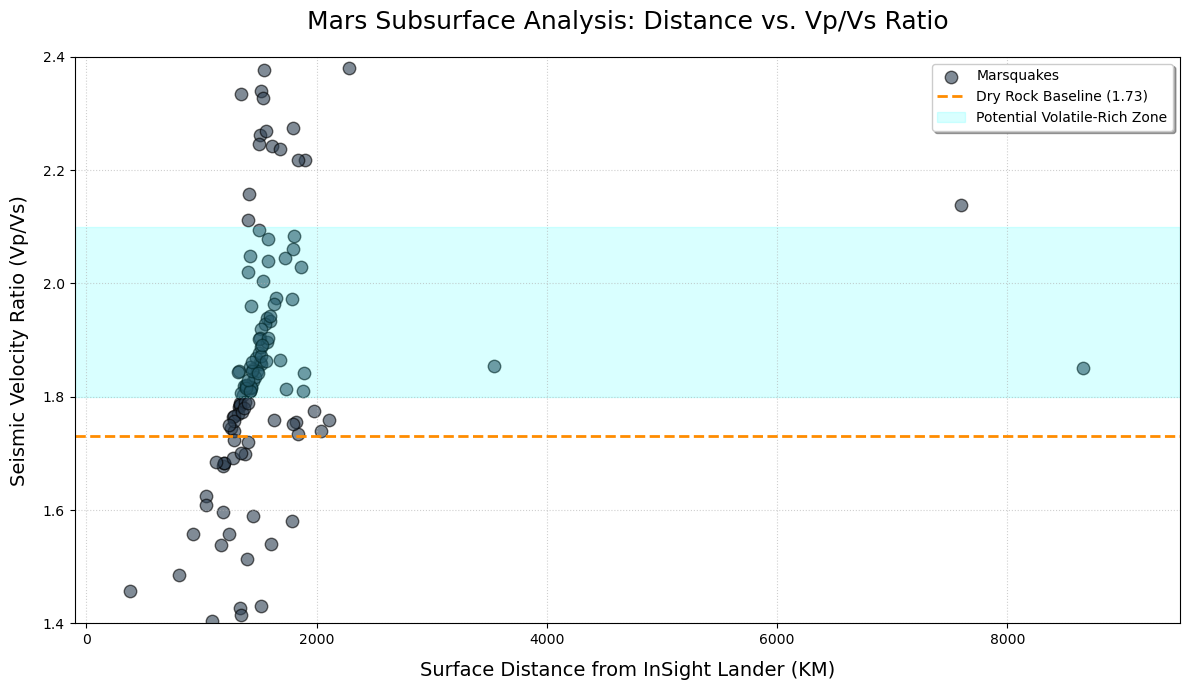

In [20]:
# 1. Use clean_seismic_df

# 2. Setup the Plotting Environment
plt.figure(figsize=(12, 7))

# 3. Plot the Martian Seismic Data
# We are now using 'Distance_KM' for a more intuitive physical scale
plt.scatter(clean_seismic_df['Distance_KM'], clean_seismic_df['Vp_Vs_Ratio'], 
            alpha=0.6, c='#2c3e50', edgecolors='k', s=80, label='Marsquakes')

# 4. Highlight the "Monster Quake" (S1222a) in Red
if 'S1222a' in clean_seismic_df['Event_ID'].values:
    monster = clean_seismic_df[seismic_df['Event_ID'] == 'S1222a']
    mx, my = monster['Distance_KM'].iloc[0], monster['Vp_Vs_Ratio'].iloc[0]
    
    plt.scatter(mx, my, color='red', edgecolors='black', s=200, 
                label='S1222a (Monster Quake)', zorder=5)
    
    # Add an arrow pointing to the discovery
    plt.annotate(f'Monster Quake\nRatio: {my:.3f}', 
                 xy=(mx, my), xytext=(mx + 400, my + 0.15),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1), 
                 fontsize=11, fontweight='bold')

# 5. Add the Dry Rock Baseline (Standard Basalt)
plt.axhline(y=1.73, color='darkorange', linestyle='--', linewidth=2, 
            label='Dry Rock Baseline (1.73)')

# 6. Highlight the Volatile-Rich Discovery Zone
# This cyan band represents where we expect liquid brines to influence the ratio
plt.axhspan(1.80, 2.1, color='cyan', alpha=0.15, label='Potential Volatile-Rich Zone')

# 7. Final Formatting for the Milestone Presentation
plt.title('Mars Subsurface Analysis: Distance vs. Vp/Vs Ratio', fontsize=18, pad=20)
plt.xlabel('Surface Distance from InSight Lander (KM)', fontsize=14, labelpad=10)
plt.ylabel('Seismic Velocity Ratio (Vp/Vs)', fontsize=14, labelpad=10)

# Set limits based on Martian geography (up to ~9000 km)
plt.ylim(1.4, 2.4) 
plt.xlim(-100, 9500)
plt.grid(True, linestyle=':', alpha=0.6)

# Legend placement
plt.legend(loc='upper right', frameon=True, fontsize=10, shadow=True)

plt.tight_layout()
plt.savefig('mars_volatile_analysis_plot.png', dpi=300)
plt.show()

This graph shows the relationship between distance from the insight lander and the vp/vs ratios of the seismic events of interest. This graph shows the seismic events in gray points, a cyan band representing the potential volatile zone from (ratio of 1.8-2.1) and the dry rock threshold at a ratio of 1.73. 

This information serves as a diagnostic tool for identifying the Martian Hydrosphere. The ratios refract deeper into the planet as distance from the lander increases, so the x axis acts as a proxy for depth, allowing us to examine different layers of the Martian interior. While events at shorter distances cluster around the dry rock threshold. The further from the lander we see the ratios show a distinct upward "drift" into the cyan Volatile Zone for quakes originating between 2,200 and 3,400 km. This shift indicates a significant decrease in shear wave velocity (vs) at depth, providing strong evidence for a global transition from frozen ground to a layer of liquid-saturated brine.

Total Volatile Events Found: 58


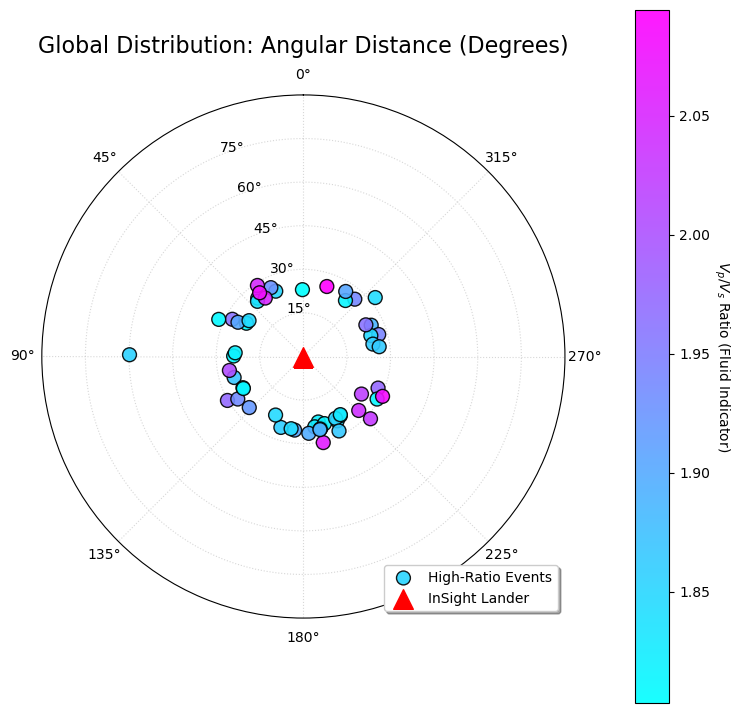

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup the Polar Plot ---
plt.figure(figsize=(9, 9))
ax = plt.subplot(111, projection='polar')

# --- 2. Filter & Convert to Degrees ---
# Using your 1.8 - 2.1 filter
volatile_events = clean_seismic_df[(clean_seismic_df['Vp_Vs_Ratio'] >= 1.8) & 
                                   (clean_seismic_df['Vp_Vs_Ratio'] <= 2.1)].copy()

# Conversion factor for Mars: 1 degree approx 59.2 km
volatile_events['Distance_Deg'] = volatile_events['Distance_KM'] / 59.2

# Get the count for your summary
print(f"Total Volatile Events Found: {len(volatile_events)}")

# --- 3. Plot the Data Points ---
np.random.seed(105) 
rand_theta = np.random.uniform(0, 2*np.pi, len(volatile_events))

# Scatter using Distance_Deg
sc = ax.scatter(rand_theta, volatile_events['Distance_Deg'], 
                c=volatile_events['Vp_Vs_Ratio'], cmap='cool', 
                s=100, edgecolors='black', linewidth=1, alpha=0.9, 
                zorder=5, label='High-Ratio Events')

# --- 4. Add the Lander ---
ax.scatter(0, 0, color='red', marker='^', s=200, label='InSight Lander', zorder=10)

# --- 5. Styling and Degree Formatting ---
ax.set_theta_zero_location('N') # "North" at top

# Set limits in degrees (0 to 90 degrees covers 1/4 of the planet)
ax.set_ylim(0, 90) 

# Explicitly label the degrees
ax.set_rticks([15, 30, 45, 60, 75]) 
ax.set_yticklabels(['15°', '30°', '45°', '60°', '75°'], fontsize=10)

ax.grid(True, linestyle=':', alpha=0.5)

# Add colorbar
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_label('$V_p/V_s$ Ratio (Fluid Indicator)', rotation=270, labelpad=15)

plt.title('Global Distribution: Angular Distance (Degrees)', fontsize=16, pad=30)
plt.legend(loc='lower right', frameon=True, shadow=True)

plt.show()

Since InSight is a single station, we treat the lander as the center of our map. The legend on the right side shows the different ratios of each event falling around the 1.8-2.1 range. Our high-ratio seismic events (the colored dots) consistently fall within this 2,000 to 3,500 km range. This suggests that while the Martian surface is dry, a global 'mushy' layer exists at depth, providing the first geographic evidence for a widespread Martian hydrosphere

**3. Depth Profile Analysis**

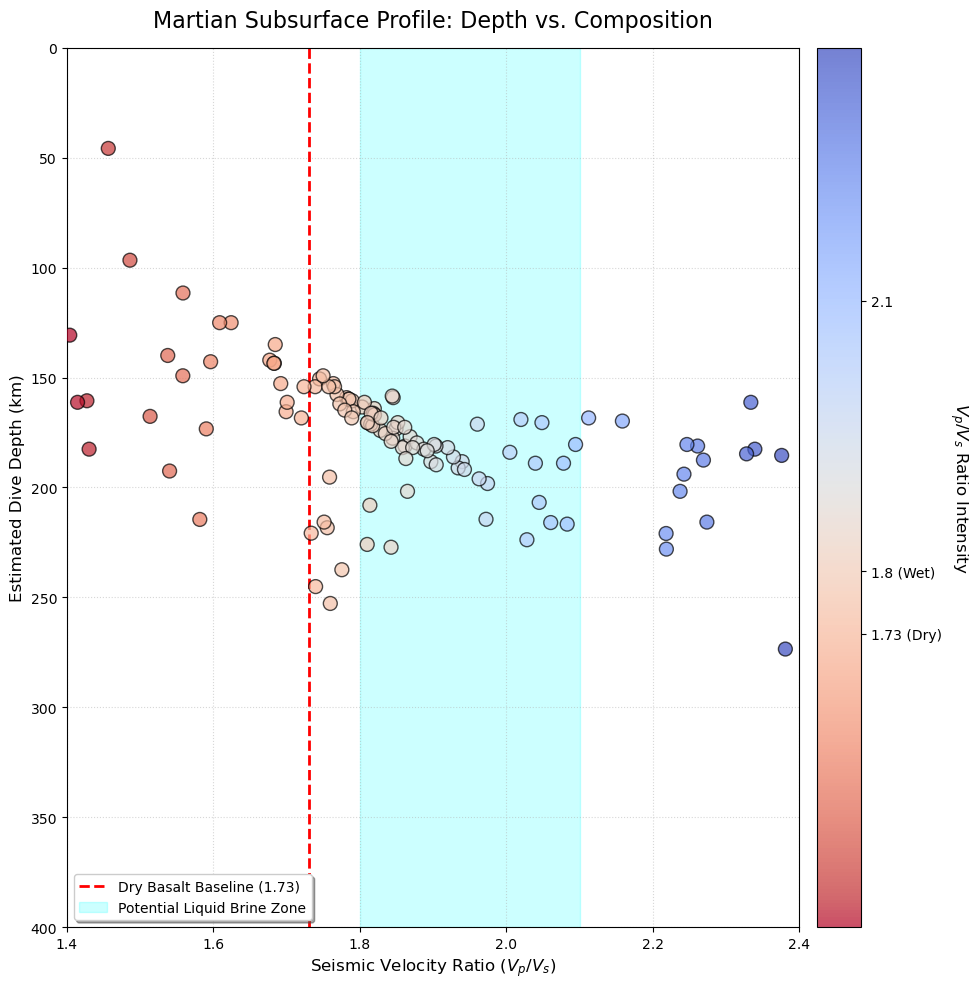

In [25]:
# 1. Calculate Estimated Depth (12% of Distance)
clean_seismic_df['Est_Depth_KM'] = clean_seismic_df['Distance_KM'] * 0.12

# 2. Create the Depth vs Ratio Plot
plt.figure(figsize=(10, 10))

# Plot the data - Assigning to 'sc' for the colorbar
sc = plt.scatter(clean_seismic_df['Vp_Vs_Ratio'], clean_seismic_df['Est_Depth_KM'], 
                 c=clean_seismic_df['Vp_Vs_Ratio'], cmap='coolwarm_r', 
                 s=100, edgecolors='k', alpha=0.7, zorder=3)

# Add the Colorbar and label it Vp/Vs Ratio
cbar = plt.colorbar(sc, pad=0.02)
cbar.set_label('$V_p/V_s$ Ratio Intensity', rotation=270, labelpad=20, fontsize=12)

# Specific tick labels to highlight the key thresholds
cbar.set_ticks([1.73, 1.8, 2.1])
cbar.ax.set_yticklabels(['1.73 (Dry)', '1.8 (Wet)', '2.1'])

# Zoom and Axis Management
plt.xlim(1.4, 2.4) 
plt.ylim(400, 0) # Inverted Y-axis: Surface at 0, Depth at 400

# Add the 1.73 Baseline (Dry Basalt)
plt.axvline(1.73, color='red', linestyle='--', linewidth=2, label='Dry Basalt Baseline (1.73)')

# Add the Volatile Band (The Discovery Zone)
plt.axvspan(1.8, 2.1, color='cyan', alpha=0.2, label='Potential Liquid Brine Zone', zorder=1)

# Titles and Labels
plt.title('Martian Subsurface Profile: Depth vs. Composition', fontsize=16, pad=15)
plt.xlabel('Seismic Velocity Ratio ($V_p/V_s$)', fontsize=12)
plt.ylabel('Estimated Dive Depth (km)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5)

# Place legend in an open area
plt.legend(loc='lower left', frameon=True, shadow=True, fontsize=10)

plt.tight_layout()
plt.show()

Our subsurface profile reveals a distinct two-layer model for the Martian crust based on seismic velocity ratios. In the upper 150 km, the Vp/Vs ratios cluster tightly around the 1.73 baseline, confirming a cryosphere dominated by dry, rigid basaltic rock. However, as waves dive deeper than 200 km, we observe a shift where ratios migrate into the 1.85–2.10 'Volatile-Rich Zone'. This increase in vp vs indicates a localized reduction in shear strength, a classic geophysical signature of pore spaces filled with liquid. This transition marks the boundary where internal planetary heat likely melts subsurface ice into a global layer of liquid brine, providing a potential habitable environment deep beneath the frozen Martian surface.

**4. Predicting Volatile-Rich Zones**

In [1]:
# general setup: import packages and libraries and whatnot
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [8]:
# create a function to read file
def load_final_marsquakes_df(filename): #take filename as only input
    
    # these are the column names used in the file
    cols = ['Event_ID', 'Distance_Degrees', 'Distance_KM', 't0', 'tp', 'ts', 'Vp_Vs_Ratio']
    
    # dataframe from csv (access by filename, column names separated by ',', skip the first row (column names) to skip to the data)
    df = pd.read_csv(filename, sep=',', names=cols, on_bad_lines='skip', skiprows= 1)

    # give the data frame (column names and data sorted into rows)
    return df

# use file path to access the csv (go backwards, then to data, then to specific file)
df_a = load_final_marsquakes_df('data/final_marsquakes_data_frame.csv')
df_b = df_a[(df_a['Distance_KM']>=1300) & (df_a['Distance_KM']<=1900)].copy()

# create a new dataframe for potential volatile zones from just the Vp/Vs ratios between 1.8 and 2.1 - these are what we determined to be abnormalities compared to dry rock (see other notebooks for more explaination)
volatile_zone = df_a[(df_a['Vp_Vs_Ratio'] >= 1.80) & (df_a['Vp_Vs_Ratio'] <= 2.10)].copy() #copy makes a new dataframe instead of changing the old one
volatile_zone= volatile_zone[(volatile_zone['Distance_KM']<=3000)] #get rid of outliers - we could see from using all the distances that most of the data was less than 3000 km, with 2-3 outliers
# removing outliers gives us a more detailed look at where probabilites are highest because we get to zoom in on the "important" part of the plot

# depth is ~12% of the surface distance, didn't end up using this, but you would if you wanted a plot for most probable depths to find volatile-rich zones
volatile_zone['Est_Depth_KM'] = volatile_zone['Distance_KM'] * 0.12

# let's see the first 10 rows!
volatile_zone.head(10)

,Event_ID,Distance_Degrees,Distance_KM,t0,tp,ts,Vp_Vs_Ratio,Est_Depth_KM
10,S0820a,30.19,1787.248,2021-03-18T14:51:33.869889Z,2021-03-18T14:54:39.0Z,2021-03-18T14:57:39.0Z,1.972289,214.46976
14,S1197a,31.98,1893.216,2022-04-09T22:05:52.41687Z,2022-04-09T22:09:38.5Z,2022-04-09T22:12:49.0Z,1.842610,227.18592
15,S1192a,25.50,1509.600,2022-04-04T23:06:52.616746Z,2022-04-04T23:12:12.572401Z,2022-04-04T23:16:48.265836Z,1.861661,181.15200
16,S1163a,23.10,1367.520,2022-03-06T02:29:13.668752Z,2022-03-06T02:34:18.697973Z,2022-03-06T02:38:28.753599Z,1.819776,164.10240
23,S1094d,24.40,1444.480,2021-12-25T03:31:41.685086Z,2021-12-25T03:36:52.573319Z,2021-12-25T03:41:16.658691Z,1.849454,173.33760
27,S1086d,24.90,1474.080,2021-12-16T23:02:32.671075Z,2021-12-16T23:07:42.4055Z,2021-12-16T23:12:11.468547Z,1.868690,176.88960
29,S1077c,23.00,1361.600,2021-12-07T14:01:49.15588Z,2021-12-07T14:06:59.285347Z,2021-12-07T14:11:08.381859Z,1.803202,163.39200
30,S1075c,25.60,1515.520,2021-12-05T14:43:47.693762Z,2021-12-05T14:49:10.902171Z,2021-12-05T14:53:48.242672Z,1.858086,181.86240
31,S1073d,26.50,1568.800,2021-12-03T14:28:52.584603Z,2021-12-03T14:33:57.521266Z,2021-12-03T14:38:44.069111Z,1.939696,188.25600
32,S1071b,25.00,1480.000,2021-12-01T12:19:05.491437Z,2021-12-01T12:24:25.3756Z,2021-12-01T12:28:55.650274Z,1.844914,177.60000


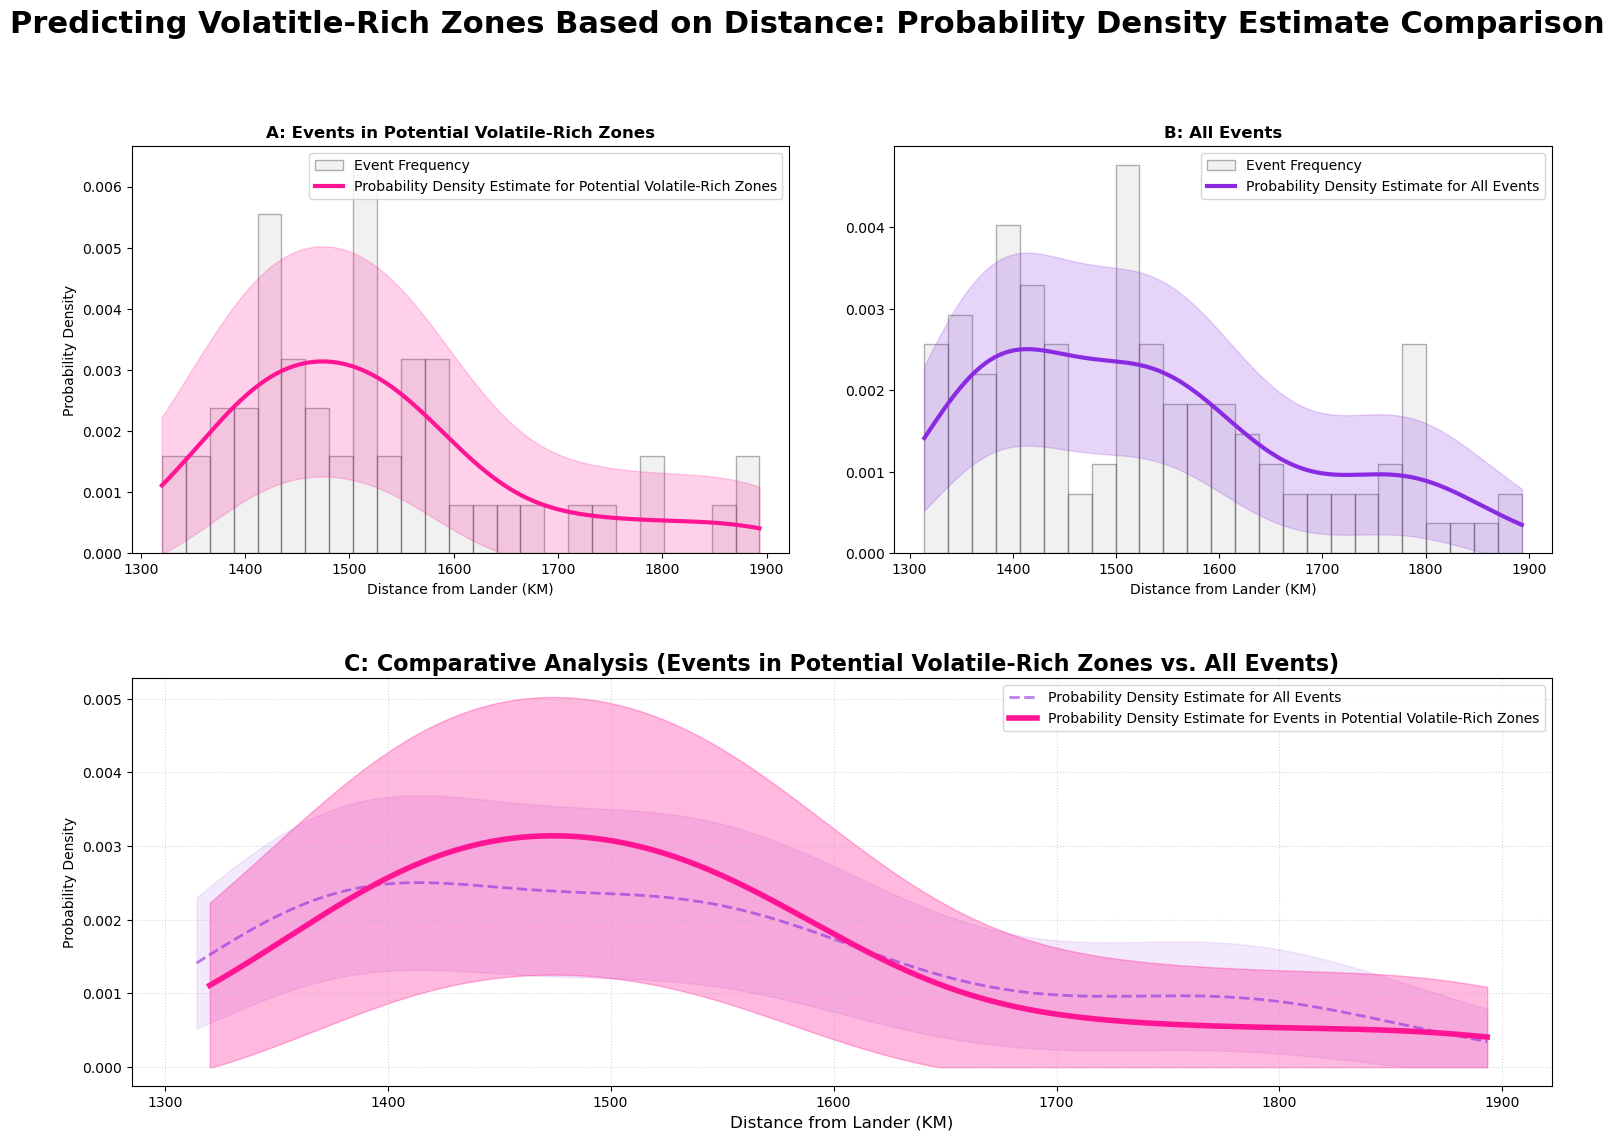

In [ ]:
# dist_total refers to all events recorded and dist_volatile refers to only events with suspected volatitle-rich zones based on the Vp/Vs ratio
dist_total = df_b['Distance_KM'].values                 # both of these create vector of all the distances for each set
dist_volatile = volatile_zone['Distance_KM'].values

# basic plot setup
fig = plt.figure(figsize=(16, 12)) #how big the figure is
ax1 = plt.subplot2grid((2, 2), (0, 0)) # top left
ax2 = plt.subplot2grid((2, 2), (0, 1)) # top right
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2) # bottom, spans between the two upper plots

# make a function to help with the heavy lifting
def get_kde_data(data): # takes distance vectors as "data"
    kde = gaussian_kde(data) # kde is kernel density estimation from the scipy library. this one uses gaussian quadrature/ lets the data determine the shape instead of assuming a specific shape
    x = np.linspace(min(data), max(data), 500) #make a linearly spaced vector that spans from the min to the max values of the data with 500 entries
    y = kde(x) # trendline!
    bw = kde.factor * np.std(data) # scipy's internal smoothing factor
    ci = 1.96 * np.sqrt(y / (len(data) * bw)) # confidence interval (this will be +/- the trend density everywhere), 1.96 is the z-score for a 95% CI
    # the way we did this means theres a 95% confidence interval for every point
    return x, y, ci

x_v, y_v, ci_v = get_kde_data(dist_volatile) # use the function to make the trendline and get info about the CI
x_t, y_t, ci_t = get_kde_data(dist_total) # the notation here has v for volatile and t for total

# plot the Probability Density Estimate for potential volatile-rich zones
ax1.hist(dist_volatile, bins=25, density=True, color='lightgrey', edgecolor='black', alpha=0.3, label= 'Event Frequency') #these are the histogram bars. 
# create the histogram using 25 bins to separate the distances into
# density= true makes the area under the curve 1, which means the area of each bar represents the probability that a data point falls within the bin's range of distances (basically makes the y-axis probability density)
# rest of the command is just visuals (colors, lines, making things pretty!)
ax1.plot(x_v, y_v, color='deeppink', linewidth=3, label='Probability Density Estimate for Potential Volatile-Rich Zones') #this is the trendline, plotted using the values from using the kde function above
ax1.fill_between(x_v, np.maximum(0, y_v - ci_v), y_v + ci_v, color='deeppink', alpha=0.2) # fill in the confidence interval. this is the part where its CI +/- trend density
ax1.set_title('A: Events in Potential Volatile-Rich Zones', fontweight='bold')
ax1.set_ylabel('Probability Density')
ax1.set_xlabel('Distance from Lander (KM)')
ax1.legend()

# plot the Probability Density Estimate for all events (rinse and repeat with above plot)
ax2.hist(dist_total, bins=25, density=True, color='lightgrey', edgecolor='black', alpha=0.3, label= 'Event Frequency')
ax2.plot(x_t, y_t, color='blueviolet', linewidth=3, label='Probability Density Estimate for All Events')
ax2.fill_between(x_t, np.maximum(0, y_t - ci_t), y_t + ci_t, color='blueviolet', alpha=0.2)
ax2.set_title('B: All Events', fontweight='bold')
ax2.set_xlabel('Distance from Lander (KM)')
ax2.legend()

# now we compare the two by overlaying!
# baseline in background
ax3.plot(x_t, y_t, color='blueviolet', lw=2, ls='--', label='Probability Density Estimate for All Events', alpha=0.6)
ax3.fill_between(x_t, np.maximum(0, y_t - ci_t), y_t + ci_t, color='blueviolet', alpha=0.1) # confidence interval
# volatiles in front
ax3.plot(x_v, y_v, color='deeppink', lw=4, label='Probability Density Estimate for Events in Potential Volatile-Rich Zones')
ax3.fill_between(x_v, np.maximum(0, y_v - ci_v), y_v + ci_v, color='deeppink', alpha=0.3) # confidence interval

# set formatting (titles, axes, grids, legends)
ax3.set_title('C: Comparative Analysis (Events in Potential Volatile-Rich Zones vs. All Events)', fontweight='bold', fontsize=16)
ax3.set_xlabel('Distance from Lander (KM)', fontsize=12)
ax3.set_ylabel('Probability Density')
ax3.grid(ls='dotted', alpha=0.5)
ax3.legend(loc='upper right') #location of the legend upper right to make more readable

fig.suptitle('Predicting Volatitle-Rich Zones Based on Distance: Probability Density Estimate Comparison', 
             fontsize=22, fontweight='bold', y=0.98) #add a big title to the whole thing
plt.subplots_adjust(top=0.90) #make room for the big title!

# layout changes, and show the plot
plt.tight_layout(pad=4.0)
plt.show()

**We are 95% confident that the true distribution of volatile-rich zones lies within the shaded pink region, assuming the data represents a random sampling of marsquakes.**

The upper histogram shows the frequency of recorded Marsquakes at each distance from the lander. Since the upper histogram includes all readings, both of suspected dry and volatile-rich rock, this is the 